# Controlled Revision Evaluation

This notebook evaluates the controlled Follow-Your-Shape revision: a fixed 12-case PartEdit-Bench subset, three fixed seeds per case, saved run configurations/logs, TDM localization metrics, and outside-target preservation metrics.

The notebook is intentionally focused on the FYS 36-run result set. The FLUX-attention localization baseline will be added as a separate method table after that baseline is implemented and run.

## 1. Setup And Paths

Define the project paths and output directory. The notebook expects to run from the repository root or from `core/notebooks`.

In [1]:
from __future__ import annotations

import csv
import json
import math
from collections import Counter
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage

try:
    import torch
    import lpips
    HAS_LPIPS = True
except Exception:
    HAS_LPIPS = False


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'core').exists():
            return candidate
    raise FileNotFoundError(f'Could not find repo root from {start}')

REPO_ROOT = find_repo_root()
MANIFEST_PATH = REPO_ROOT / 'core/data/partedit_subset/pilot_12_manifest.json'
RUN_MATRIX_PATH = REPO_ROOT / 'core/results/run_matrices/pilot_12_manifest_multi_seed.csv'
FLUX_ATTENTION_MATRIX_PATH = REPO_ROOT / 'core/results/run_matrices/flux_attention_baseline_matrix.csv'
FYS_ROOT = REPO_ROOT / 'core/results/follow_your_shape'
FLUX_ATTENTION_ROOT = REPO_ROOT / 'core/results/flux_attention_baseline'
OUTPUT_DIR = REPO_ROOT / 'core/results/controlled_revision'
FIGURE_DIR = OUTPUT_DIR / 'figures'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print('repo:', REPO_ROOT)
print('manifest:', MANIFEST_PATH.exists(), MANIFEST_PATH)
print('run matrix:', RUN_MATRIX_PATH.exists(), RUN_MATRIX_PATH)
print('FYS root:', FYS_ROOT.exists(), FYS_ROOT)
print('FLUX attention matrix:', FLUX_ATTENTION_MATRIX_PATH.exists(), FLUX_ATTENTION_MATRIX_PATH)
print('FLUX attention root:', FLUX_ATTENTION_ROOT.exists(), FLUX_ATTENTION_ROOT)
print('LPIPS available:', HAS_LPIPS)

repo: /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting
manifest: True /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/data/partedit_subset/pilot_12_manifest.json
run matrix: True /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/run_matrices/pilot_12_manifest_multi_seed.csv
FYS root: True /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/follow_your_shape
FLUX attention matrix: True /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/run_matrices/flux_attention_baseline_matrix.csv
FLUX attention root: True /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/flux_attention_baseline
LPIPS available: False


## 2. Load Controlled-Revision Runs

Load the fixed 12-case manifest, the generated 36-run matrix, and the actual result directories. Each row in the main table corresponds to one `(case_uid, seed)` run.

In [2]:
manifest_records = json.loads(MANIFEST_PATH.read_text())
manifest_df = pd.DataFrame(manifest_records)
run_matrix = pd.read_csv(RUN_MATRIX_PATH)

print('manifest cases:', len(manifest_df))
print('run matrix rows:', len(run_matrix))
print('manifest part-size distribution:')
display(manifest_df['part_size'].value_counts().rename_axis('part_size').reset_index(name='cases'))
print('run seed distribution:')
display(run_matrix['seed'].value_counts().sort_index().rename_axis('seed').reset_index(name='runs'))

manifest cases: 12
run matrix rows: 36
manifest part-size distribution:


,part_size,cases
0,small,4
1,medium,4
2,large,4


run seed distribution:


,seed,runs
0,0,12
1,1,12
2,2,12


In [3]:
def first_existing_image(run_dir: Path) -> Path | None:
    images = sorted(run_dir.glob('img_*.jpg'))
    return images[0] if images else None

rows: list[dict[str, Any]] = []
for record in manifest_records:
    case_uid = record['case_uid']
    for seed in [0, 1, 2]:
        run_dir = FYS_ROOT / case_uid / f'seed_{seed:03d}'
        tdm_dir = run_dir / 'tdm'
        rows.append({
            **{k: record.get(k) for k in [
                'case_uid', 'dataset_split', 'dataset_index', 'class_name', 'subject',
                'part', 'normalized_part', 'part_size', 'mask_area_ratio', 'edit',
                'source_prompt', 'target_prompt', 'source_image', 'gt_mask', 'partedit_reference'
            ]},
            'seed': seed,
            'run_uid': f'{case_uid}_seed_{seed:03d}',
            'run_dir': run_dir,
            'run_config_path': run_dir / 'run_config.json',
            'run_log_path': run_dir / 'run.log',
            'fys_image_path': first_existing_image(run_dir),
            'binary_tdm_path': tdm_dir / 'binary_tdm_mask.npy',
            'smoothed_tdm_path': tdm_dir / 'smoothed_soft_tdm.npy',
            'aggregated_tdm_path': tdm_dir / 'aggregated_soft_tdm.npy',
            'tdm_metadata_path': tdm_dir / 'tdm_metadata.json',
        })

runs = pd.DataFrame(rows)
for col in ['source_image', 'gt_mask', 'partedit_reference']:
    runs[col + '_path'] = runs[col].apply(lambda p: REPO_ROOT / p)

runs.head()

,case_uid,dataset_split,dataset_index,class_name,subject,part,normalized_part,part_size,mask_area_ratio,edit,...,run_config_path,run_log_path,fys_image_path,binary_tdm_path,smoothed_tdm_path,aggregated_tdm_path,tdm_metadata_path,source_image_path,gt_mask_path,partedit_reference_path
0,real_0006,real,6,animal_head,man,head,head,small,0.007187,alien,...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...
1,real_0006,real,6,animal_head,man,head,head,small,0.007187,alien,...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...
2,real_0006,real,6,animal_head,man,head,head,small,0.007187,alien,...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...
3,real_0008,real,8,animal_head,dog,head,head,small,0.024128,bear,...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...
4,real_0008,real,8,animal_head,dog,head,head,small,0.024128,bear,...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...,/Users/pt623/Documents/career-vault-resume/app...


## 3. Validate Run Completeness

Check whether every controlled run has the expected configuration, log, edited image, and TDM artifacts. This directly verifies the completed part of Harry's requested controlled run protocol.

In [4]:
artifact_columns = [
    'run_config_path',
    'run_log_path',
    'fys_image_path',
    'binary_tdm_path',
    'smoothed_tdm_path',
    'aggregated_tdm_path',
    'tdm_metadata_path',
    'source_image_path',
    'gt_mask_path',
]

for col in artifact_columns:
    runs[col + '_exists'] = runs[col].apply(lambda p: p is not None and Path(p).exists())

completeness = []
for col in artifact_columns:
    completeness.append({
        'artifact': col,
        'present': int(runs[col + '_exists'].sum()),
        'expected': len(runs),
        'complete': bool(runs[col + '_exists'].all()),
    })
completeness_df = pd.DataFrame(completeness)
display(completeness_df)

missing_rows = []
for _, row in runs.iterrows():
    for col in artifact_columns:
        if not row[col + '_exists']:
            missing_rows.append({'run_uid': row['run_uid'], 'missing_artifact': col, 'path': str(row[col])})
missing_artifacts = pd.DataFrame(missing_rows)
missing_artifacts

,artifact,present,expected,complete
0,run_config_path,36,36,True
1,run_log_path,36,36,True
2,fys_image_path,36,36,True
3,binary_tdm_path,36,36,True
4,smoothed_tdm_path,36,36,True
5,aggregated_tdm_path,36,36,True
6,tdm_metadata_path,36,36,True
7,source_image_path,36,36,True
8,gt_mask_path,36,36,True


""


In [5]:
error_patterns = ['Traceback', 'Error', 'FAILED', 'FileNotFoundError', 'CUDA out of memory', 'RuntimeError']
safety_patterns = ['NSFW', 'may contain']
log_scan_rows = []
for _, row in runs.iterrows():
    log_path = row['run_log_path']
    text = log_path.read_text(errors='replace') if log_path.exists() else ''
    log_scan_rows.append({
        'run_uid': row['run_uid'],
        'has_error_pattern': any(pattern in text for pattern in error_patterns),
        'has_safety_filter_pattern': any(pattern in text for pattern in safety_patterns),
        'log_tail': text[-500:],
    })
log_scan = pd.DataFrame(log_scan_rows)
display(log_scan[['has_error_pattern', 'has_safety_filter_pattern']].sum().to_frame('count'))
log_scan.query('has_error_pattern or has_safety_filter_pattern')

,count
has_error_pattern,0
has_safety_filter_pattern,0


,run_uid,has_error_pattern,has_safety_filter_pattern,log_tail


## 4. Metric Helpers

The TDM patch grid is resized to image resolution for evaluation only. Raw TDM `.npy` artifacts are not modified. LPIPS is optional and is computed only when `torch` and `lpips` are available, preferably on the GPU server.

The notebook uses an automatic LPIPS policy: if LPIPS is available, it recomputes and updates `outside_mask_lpips`; if LPIPS is unavailable, it preserves any existing server-side LPIPS values in `fys_run_metrics.csv` by `run_uid`.

In [6]:
def load_rgb(path: Path, size: tuple[int, int] | None = None) -> np.ndarray:
    image = Image.open(path).convert('RGB')
    if size is not None and image.size != size:
        image = image.resize(size, Image.Resampling.BICUBIC)
    return np.asarray(image).astype(np.float32) / 255.0


def load_mask(path: Path, size: tuple[int, int] | None = None) -> np.ndarray:
    mask = Image.open(path).convert('L')
    if size is not None and mask.size != size:
        mask = mask.resize(size, Image.Resampling.NEAREST)
    return np.asarray(mask) > 0


def load_tdm(path: Path, image_size: tuple[int, int], is_binary: bool = False) -> np.ndarray:
    arr = np.load(path)
    if arr.ndim == 3:
        arr = arr.squeeze()
    if arr.dtype == bool:
        is_binary = True
    arr_float = arr.astype(np.float32)
    if arr_float.max() > arr_float.min():
        norm = (arr_float - arr_float.min()) / (arr_float.max() - arr_float.min())
    else:
        norm = np.zeros_like(arr_float, dtype=np.float32)
    pil = Image.fromarray((norm * 255).astype(np.uint8), mode='L')
    resample = Image.Resampling.NEAREST if is_binary else Image.Resampling.BICUBIC
    pil = pil.resize(image_size, resample=resample)
    out = np.asarray(pil).astype(np.float32) / 255.0
    return out > 0.5 if is_binary else out


def binary_iou(pred: np.ndarray, gt: np.ndarray) -> float:
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    union = np.logical_or(pred, gt).sum()
    if union == 0:
        return float('nan')
    return float(np.logical_and(pred, gt).sum() / union)


def average_precision_from_scores(scores: np.ndarray, labels: np.ndarray) -> float:
    scores = scores.reshape(-1).astype(np.float64)
    labels = labels.reshape(-1).astype(bool)
    positives = labels.sum()
    if positives == 0:
        return float('nan')
    order = np.argsort(-scores)
    sorted_labels = labels[order]
    tp = np.cumsum(sorted_labels)
    precision = tp / (np.arange(len(sorted_labels)) + 1)
    return float((precision * sorted_labels).sum() / positives)


def soft_inside_mass(scores: np.ndarray, gt: np.ndarray) -> float:
    total = float(scores.sum())
    if total <= 0:
        return float('nan')
    return float(scores[gt.astype(bool)].sum() / total)


def masked_l1(source: np.ndarray, edited: np.ndarray, mask: np.ndarray) -> float:
    selected = mask.astype(bool)
    if selected.sum() == 0:
        return float('nan')
    return float(np.abs(source[selected] - edited[selected]).mean())


def masked_mse(source: np.ndarray, edited: np.ndarray, mask: np.ndarray) -> float:
    selected = mask.astype(bool)
    if selected.sum() == 0:
        return float('nan')
    return float(((source[selected] - edited[selected]) ** 2).mean())


def psnr_from_mse(mse: float) -> float:
    if not np.isfinite(mse):
        return float('nan')
    if mse <= 1e-12:
        return float('inf')
    return float(10 * math.log10(1.0 / mse))


def masked_global_ssim(source: np.ndarray, edited: np.ndarray, mask: np.ndarray) -> float:
    # Lightweight masked SSIM proxy over selected grayscale pixels. This is not windowed SSIM.
    selected = mask.astype(bool)
    if selected.sum() < 2:
        return float('nan')
    src_gray = (0.299 * source[..., 0] + 0.587 * source[..., 1] + 0.114 * source[..., 2])[selected]
    edt_gray = (0.299 * edited[..., 0] + 0.587 * edited[..., 1] + 0.114 * edited[..., 2])[selected]
    c1 = 0.01 ** 2
    c2 = 0.03 ** 2
    mu_x = src_gray.mean()
    mu_y = edt_gray.mean()
    var_x = src_gray.var()
    var_y = edt_gray.var()
    cov_xy = ((src_gray - mu_x) * (edt_gray - mu_y)).mean()
    numerator = (2 * mu_x * mu_y + c1) * (2 * cov_xy + c2)
    denominator = (mu_x ** 2 + mu_y ** 2 + c1) * (var_x + var_y + c2)
    return float(numerator / denominator) if denominator != 0 else float('nan')

## 5. FYS Localization And Preservation Metrics

Compute run-level metrics for all 36 FYS runs. Localization metrics evaluate TDM maps against the GT part mask. Preservation metrics compare the source and edited images outside the GT part mask.

In [7]:
lpips_model = None
if HAS_LPIPS:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    lpips_model = lpips.LPIPS(net='alex').to(device).eval()
    print('LPIPS device:', device)
else:
    print('LPIPS unavailable; existing LPIPS values will be preserved when available.')


def optional_outside_lpips(source: np.ndarray, edited: np.ndarray, gt_mask: np.ndarray) -> float:
    if lpips_model is None:
        return float('nan')
    outside = (~gt_mask.astype(bool))[..., None].astype(np.float32)
    # Neutralize the edited region so LPIPS is dominated by the outside area.
    neutral = np.full_like(source, 0.5, dtype=np.float32)
    source_outside = source * outside + neutral * (1 - outside)
    edited_outside = edited * outside + neutral * (1 - outside)
    src_tensor = torch.from_numpy(source_outside.transpose(2, 0, 1)).unsqueeze(0) * 2 - 1
    edt_tensor = torch.from_numpy(edited_outside.transpose(2, 0, 1)).unsqueeze(0) * 2 - 1
    src_tensor = src_tensor.to(next(lpips_model.parameters()).device).float()
    edt_tensor = edt_tensor.to(next(lpips_model.parameters()).device).float()
    with torch.no_grad():
        return float(lpips_model(src_tensor, edt_tensor).item())

LPIPS unavailable; existing LPIPS values will be preserved when available.


In [8]:
fys_run_metrics_path = OUTPUT_DIR / 'fys_run_metrics.csv'
existing_lpips = None
if fys_run_metrics_path.exists():
    existing_metrics = pd.read_csv(fys_run_metrics_path, dtype={'run_uid': str})
    if 'outside_mask_lpips' in existing_metrics.columns:
        existing_lpips = existing_metrics[['run_uid', 'outside_mask_lpips']].copy()
        existing_lpips['outside_mask_lpips'] = pd.to_numeric(existing_lpips['outside_mask_lpips'], errors='coerce')
        print('found existing LPIPS values:', existing_lpips['outside_mask_lpips'].notna().sum())

metric_rows = []
for _, row in runs.iterrows():
    source_path = row['source_image_path']
    gt_path = row['gt_mask_path']
    edited_path = row['fys_image_path']
    image_size = Image.open(source_path).size
    source = load_rgb(source_path)
    edited = load_rgb(edited_path, size=image_size)
    gt_mask = load_mask(gt_path, size=image_size)
    outside_mask = ~gt_mask

    binary_tdm = load_tdm(row['binary_tdm_path'], image_size, is_binary=True)
    soft_tdm = load_tdm(row['smoothed_tdm_path'], image_size, is_binary=False)
    pred_tdm_area = float(binary_tdm.mean())
    gt_area = float(gt_mask.mean())
    outside_mse = masked_mse(source, edited, outside_mask)
    inside_mse = masked_mse(source, edited, gt_mask)

    metric_rows.append({
        'run_uid': row['run_uid'],
        'case_uid': row['case_uid'],
        'seed': row['seed'],
        'part_size': row['part_size'],
        'part': row['part'],
        'edit': row['edit'],
        'gt_area': gt_area,
        'pred_tdm_area': pred_tdm_area,
        'pred_to_gt_area_ratio': float(pred_tdm_area / gt_area) if gt_area > 0 else float('nan'),
        'binary_iou': binary_iou(binary_tdm, gt_mask),
        'soft_ap': average_precision_from_scores(soft_tdm, gt_mask),
        'soft_inside_gt_mass': soft_inside_mass(soft_tdm, gt_mask),
        'outside_mask_l1_aux': masked_l1(source, edited, outside_mask),
        'inside_mask_l1_aux': masked_l1(source, edited, gt_mask),
        'outside_mask_mse': outside_mse,
        'inside_mask_mse': inside_mse,
        'outside_mask_psnr': psnr_from_mse(outside_mse),
        'inside_mask_psnr': psnr_from_mse(inside_mse),
        'outside_mask_global_ssim': masked_global_ssim(source, edited, outside_mask),
        'inside_mask_global_ssim': masked_global_ssim(source, edited, gt_mask),
        'outside_mask_lpips': optional_outside_lpips(source, edited, gt_mask),
        'source_image': str(row['source_image']),
        'gt_mask': str(row['gt_mask']),
        'fys_image': str(row['fys_image_path'].relative_to(REPO_ROOT)),
        'binary_tdm_path': str(row['binary_tdm_path'].relative_to(REPO_ROOT)),
        'smoothed_tdm_path': str(row['smoothed_tdm_path'].relative_to(REPO_ROOT)),
    })

fys_run_metrics = pd.DataFrame(metric_rows)
if existing_lpips is not None:
    fys_run_metrics = fys_run_metrics.merge(existing_lpips, on='run_uid', how='left', suffixes=('', '_existing'))
    preserve_existing = fys_run_metrics['outside_mask_lpips'].isna() & fys_run_metrics['outside_mask_lpips_existing'].notna()
    fys_run_metrics.loc[preserve_existing, 'outside_mask_lpips'] = fys_run_metrics.loc[preserve_existing, 'outside_mask_lpips_existing']
    fys_run_metrics = fys_run_metrics.drop(columns=['outside_mask_lpips_existing'])
    print('preserved existing LPIPS values:', int(preserve_existing.sum()))

fys_run_metrics.to_csv(fys_run_metrics_path, index=False)
print('saved:', fys_run_metrics_path)
print('LPIPS non-empty after save:', fys_run_metrics['outside_mask_lpips'].notna().sum())
display(fys_run_metrics.head())

found existing LPIPS values: 36


/var/folders/h8/4tqmd6qs19zcccxsg4_xc7c00000gp/T/ipykernel_35882/3041514674.py:26: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray((norm * 255).astype(np.uint8), mode='L')


preserved existing LPIPS values: 36
saved: /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/controlled_revision/fys_run_metrics.csv
LPIPS non-empty after save: 36


,run_uid,case_uid,seed,part_size,part,edit,gt_area,pred_tdm_area,pred_to_gt_area_ratio,binary_iou,...,outside_mask_psnr,inside_mask_psnr,outside_mask_global_ssim,inside_mask_global_ssim,outside_mask_lpips,source_image,gt_mask,fys_image,binary_tdm_path,smoothed_tdm_path
0,real_0006_seed_000,real_0006,0,small,head,alien,0.007187,0.246094,34.242038,0.029204,...,17.609344,10.567388,0.869110,0.426229,0.228013,core/data/partedit_subset/cases/real_0006/sour...,core/data/partedit_subset/cases/real_0006/gt_m...,core/results/follow_your_shape/real_0006/seed_...,core/results/follow_your_shape/real_0006/seed_...,core/results/follow_your_shape/real_0006/seed_...
1,real_0006_seed_001,real_0006,1,small,head,alien,0.007187,0.246094,34.242038,0.029204,...,17.609344,10.567388,0.869110,0.426229,0.228013,core/data/partedit_subset/cases/real_0006/sour...,core/data/partedit_subset/cases/real_0006/gt_m...,core/results/follow_your_shape/real_0006/seed_...,core/results/follow_your_shape/real_0006/seed_...,core/results/follow_your_shape/real_0006/seed_...
2,real_0006_seed_002,real_0006,2,small,head,alien,0.007187,0.246094,34.242038,0.029204,...,17.609344,10.567388,0.869110,0.426229,0.228013,core/data/partedit_subset/cases/real_0006/sour...,core/data/partedit_subset/cases/real_0006/gt_m...,core/results/follow_your_shape/real_0006/seed_...,core/results/follow_your_shape/real_0006/seed_...,core/results/follow_your_shape/real_0006/seed_...
3,real_0008_seed_000,real_0008,0,small,head,bear,0.024128,0.359375,14.894545,0.067139,...,21.743052,15.684919,0.954239,0.815645,0.198043,core/data/partedit_subset/cases/real_0008/sour...,core/data/partedit_subset/cases/real_0008/gt_m...,core/results/follow_your_shape/real_0008/seed_...,core/results/follow_your_shape/real_0008/seed_...,core/results/follow_your_shape/real_0008/seed_...
4,real_0008_seed_001,real_0008,1,small,head,bear,0.024128,0.359375,14.894545,0.067139,...,21.743052,15.684919,0.954239,0.815645,0.198043,core/data/partedit_subset/cases/real_0008/sour...,core/data/partedit_subset/cases/real_0008/gt_m...,core/results/follow_your_shape/real_0008/seed_...,core/results/follow_your_shape/real_0008/seed_...,core/results/follow_your_shape/real_0008/seed_...


## 6. FLUX Target-Token Attention Baseline Metrics

This section evaluates the plain-FLUX target-token attention localization baseline using the same GT part masks and the same localization metrics as FYS TDM. The baseline uses the same inverted latent `z` and target prompt, but no FYS KV injection and no oracle mask.

In [9]:
flux_attention_rows = []
for record in manifest_records:
    case_uid = record['case_uid']
    for seed in [0, 1, 2]:
        run_uid = f'{case_uid}_seed_{seed:03d}'
        run_dir = FLUX_ATTENTION_ROOT / case_uid / f'seed_{seed:03d}'
        source_path = REPO_ROOT / record['source_image']
        gt_path = REPO_ROOT / record['gt_mask']
        image_size = Image.open(source_path).size
        gt_mask = load_mask(gt_path, size=image_size)

        raw_path = run_dir / 'attention_proxy_raw.npy'
        smoothed_path = run_dir / 'attention_proxy_smoothed.npy'
        binary_path = run_dir / 'attention_proxy_binary.npy'
        config_path = run_dir / 'run_config.json'
        log_path = run_dir / 'run.log'

        if not all(path.exists() for path in [raw_path, smoothed_path, binary_path, config_path, log_path]):
            raise FileNotFoundError(f'Missing FLUX attention baseline artifacts for {run_uid}: {run_dir}')

        soft_attention = load_tdm(smoothed_path, image_size, is_binary=False)
        binary_attention = load_tdm(binary_path, image_size, is_binary=True)
        pred_attention_area = float(binary_attention.mean())
        gt_area = float(gt_mask.mean())
        config = json.loads(config_path.read_text())

        flux_attention_rows.append({
            'run_uid': run_uid,
            'case_uid': case_uid,
            'seed': seed,
            'part_size': record['part_size'],
            'part': record['part'],
            'edit': record['edit'],
            'source_prompt': record['source_prompt'],
            'target_prompt': record['target_prompt'],
            'gt_area': gt_area,
            'pred_attention_area': pred_attention_area,
            'pred_to_gt_area_ratio': float(pred_attention_area / gt_area) if gt_area > 0 else float('nan'),
            'binary_iou': binary_iou(binary_attention, gt_mask),
            'soft_ap': average_precision_from_scores(soft_attention, gt_mask),
            'soft_inside_gt_mass': soft_inside_mass(soft_attention, gt_mask),
            'attention_raw_path': str(raw_path.relative_to(REPO_ROOT)),
            'attention_smoothed_path': str(smoothed_path.relative_to(REPO_ROOT)),
            'attention_binary_path': str(binary_path.relative_to(REPO_ROOT)),
            'attention_config_path': str(config_path.relative_to(REPO_ROOT)),
            'attention_log_path': str(log_path.relative_to(REPO_ROOT)),
            'token_indices': config.get('token_indices'),
            'recorded_step_indices': config.get('recorded_step_indices'),
            'layer_ids': config.get('layer_ids'),
        })

flux_attention_metrics = pd.DataFrame(flux_attention_rows)
flux_attention_metrics_path = OUTPUT_DIR / 'flux_attention_metrics.csv'
flux_attention_metrics.to_csv(flux_attention_metrics_path, index=False)
print('saved:', flux_attention_metrics_path)
print('baseline rows:', len(flux_attention_metrics))
display(flux_attention_metrics.head())

flux_attention_completeness = pd.DataFrame([
    {'artifact': 'attention_proxy_raw.npy', 'present': len(list(FLUX_ATTENTION_ROOT.glob('*/seed_*/attention_proxy_raw.npy'))), 'expected': len(flux_attention_metrics)},
    {'artifact': 'attention_proxy_smoothed.npy', 'present': len(list(FLUX_ATTENTION_ROOT.glob('*/seed_*/attention_proxy_smoothed.npy'))), 'expected': len(flux_attention_metrics)},
    {'artifact': 'attention_proxy_binary.npy', 'present': len(list(FLUX_ATTENTION_ROOT.glob('*/seed_*/attention_proxy_binary.npy'))), 'expected': len(flux_attention_metrics)},
    {'artifact': 'run_config.json', 'present': len(list(FLUX_ATTENTION_ROOT.glob('*/seed_*/run_config.json'))), 'expected': len(flux_attention_metrics)},
])
display(flux_attention_completeness)

/var/folders/h8/4tqmd6qs19zcccxsg4_xc7c00000gp/T/ipykernel_35882/3041514674.py:26: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray((norm * 255).astype(np.uint8), mode='L')


saved: /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/controlled_revision/flux_attention_metrics.csv
baseline rows: 36


,run_uid,case_uid,seed,part_size,part,edit,source_prompt,target_prompt,gt_area,pred_attention_area,...,soft_ap,soft_inside_gt_mass,attention_raw_path,attention_smoothed_path,attention_binary_path,attention_config_path,attention_log_path,token_indices,recorded_step_indices,layer_ids
0,real_0006_seed_000,real_0006,0,small,head,alien,a man standing in a park wearing a green shirt,a man with alien head standing in a park weari...,0.007187,0.267578,...,0.055930,0.019802,core/results/flux_attention_baseline/real_0006...,core/results/flux_attention_baseline/real_0006...,core/results/flux_attention_baseline/real_0006...,core/results/flux_attention_baseline/real_0006...,core/results/flux_attention_baseline/real_0006...,"[4, 5]","[2, 3, 4, 5, 6, 7, 8]","[28, 29, 30, 31, 32, 33, 34, 35, 36, 37]"
1,real_0006_seed_001,real_0006,1,small,head,alien,a man standing in a park wearing a green shirt,a man with alien head standing in a park weari...,0.007187,0.267578,...,0.055930,0.019802,core/results/flux_attention_baseline/real_0006...,core/results/flux_attention_baseline/real_0006...,core/results/flux_attention_baseline/real_0006...,core/results/flux_attention_baseline/real_0006...,core/results/flux_attention_baseline/real_0006...,"[4, 5]","[2, 3, 4, 5, 6, 7, 8]","[28, 29, 30, 31, 32, 33, 34, 35, 36, 37]"
2,real_0006_seed_002,real_0006,2,small,head,alien,a man standing in a park wearing a green shirt,a man with alien head standing in a park weari...,0.007187,0.267578,...,0.055930,0.019802,core/results/flux_attention_baseline/real_0006...,core/results/flux_attention_baseline/real_0006...,core/results/flux_attention_baseline/real_0006...,core/results/flux_attention_baseline/real_0006...,core/results/flux_attention_baseline/real_0006...,"[4, 5]","[2, 3, 4, 5, 6, 7, 8]","[28, 29, 30, 31, 32, 33, 34, 35, 36, 37]"
3,real_0008_seed_000,real_0008,0,small,head,bear,a dog standing in a field with grass and water,a dog with bear head standing in a field with ...,0.024128,0.267578,...,0.851204,0.091690,core/results/flux_attention_baseline/real_0008...,core/results/flux_attention_baseline/real_0008...,core/results/flux_attention_baseline/real_0008...,core/results/flux_attention_baseline/real_0008...,core/results/flux_attention_baseline/real_0008...,"[4, 5]","[2, 3, 4, 5, 6, 7, 8]","[28, 29, 30, 31, 32, 33, 34, 35, 36, 37]"
4,real_0008_seed_001,real_0008,1,small,head,bear,a dog standing in a field with grass and water,a dog with bear head standing in a field with ...,0.024128,0.267578,...,0.851204,0.091690,core/results/flux_attention_baseline/real_0008...,core/results/flux_attention_baseline/real_0008...,core/results/flux_attention_baseline/real_0008...,core/results/flux_attention_baseline/real_0008...,core/results/flux_attention_baseline/real_0008...,"[4, 5]","[2, 3, 4, 5, 6, 7, 8]","[28, 29, 30, 31, 32, 33, 34, 35, 36, 37]"


,artifact,present,expected
0,attention_proxy_raw.npy,36,36
1,attention_proxy_smoothed.npy,36,36
2,attention_proxy_binary.npy,36,36
3,run_config.json,36,36


## 7. Seed Stability Analysis

Aggregate the 3 fixed seeds for each case. This summarizes whether the controlled seeds produce stable localization and preservation metrics.

In [10]:
metric_cols = [
    'binary_iou',
    'soft_ap',
    'pred_to_gt_area_ratio',
    'soft_inside_gt_mass',
    'outside_mask_l1_aux',
    'outside_mask_psnr',
    'outside_mask_global_ssim',
    'outside_mask_lpips',
]

case_summary = (
    fys_run_metrics
    .groupby(['case_uid', 'part_size', 'part', 'edit'], as_index=False)[metric_cols]
    .agg(['mean', 'std'])
)
case_summary.columns = ['_'.join(col).strip('_') for col in case_summary.columns.to_flat_index()]
display(case_summary)

,case_uid,part_size,part,edit,binary_iou_mean,binary_iou_std,soft_ap_mean,soft_ap_std,pred_to_gt_area_ratio_mean,pred_to_gt_area_ratio_std,soft_inside_gt_mass_mean,soft_inside_gt_mass_std,outside_mask_l1_aux_mean,outside_mask_l1_aux_std,outside_mask_psnr_mean,outside_mask_psnr_std,outside_mask_global_ssim_mean,outside_mask_global_ssim_std,outside_mask_lpips_mean,outside_mask_lpips_std
0,real_0000,large,torso,armored,0.219518,0.0,0.235943,0.0,4.298006,0.0,0.164590,0.0,0.046519,0.0,19.774179,0.0,0.883964,0.0,0.209603,0.0
1,real_0001,medium,head,cat,0.264327,0.0,0.414231,0.0,3.618193,0.0,0.151131,0.0,0.054304,0.0,21.501335,0.0,0.874552,0.0,0.207193,0.0
2,real_0002,small,seat,mesh,0.050040,0.0,0.051869,0.0,10.349700,0.0,0.042822,0.0,0.046172,0.0,21.723971,0.0,0.964104,0.0,0.142717,0.0
3,real_0003,small,head,cheetah,0.044741,0.0,0.043715,0.0,8.450039,0.0,0.038513,0.0,0.060924,0.0,18.412814,0.0,0.925958,0.0,0.208526,0.0
4,real_0004,medium,carhood,rusted,0.156007,0.0,0.265689,0.0,6.283438,0.0,0.125814,0.0,0.068945,0.0,18.020972,0.0,0.872189,0.0,0.184868,0.0
5,real_0005,large,head,dog,0.341621,0.0,0.396299,0.0,2.517614,0.0,0.198702,0.0,0.067070,0.0,20.348834,0.0,0.914569,0.0,0.186346,0.0
6,real_0006,small,head,alien,0.029204,0.0,0.242928,0.0,34.242038,0.0,0.025541,0.0,0.081325,0.0,17.609344,0.0,0.869110,0.0,0.228013,0.0
7,real_0007,medium,seat,leather,0.126169,0.0,0.135050,0.0,3.532871,0.0,0.102225,0.0,0.032623,0.0,21.396551,0.0,0.940474,0.0,0.136344,0.0
8,real_0008,small,head,bear,0.067139,0.0,0.159411,0.0,14.894545,0.0,0.057989,0.0,0.047415,0.0,21.743052,0.0,0.954239,0.0,0.198043,0.0
9,real_0009,large,carbody,rusted,0.508312,0.0,0.651605,0.0,0.980005,0.0,0.510670,0.0,0.037351,0.0,23.104263,0.0,0.959767,0.0,0.149899,0.0


In [11]:
part_size_summary = (
    fys_run_metrics
    .groupby('part_size')[metric_cols]
    .agg(['count', 'mean', 'std', 'median'])
)
part_size_summary.columns = ['_'.join(col).strip('_') for col in part_size_summary.columns.to_flat_index()]
part_size_summary = part_size_summary.reset_index()
display(part_size_summary)

,part_size,binary_iou_count,binary_iou_mean,binary_iou_std,binary_iou_median,soft_ap_count,soft_ap_mean,soft_ap_std,soft_ap_median,pred_to_gt_area_ratio_count,...,outside_mask_psnr_std,outside_mask_psnr_median,outside_mask_global_ssim_count,outside_mask_global_ssim_mean,outside_mask_global_ssim_std,outside_mask_global_ssim_median,outside_mask_lpips_count,outside_mask_lpips_mean,outside_mask_lpips_std,outside_mask_lpips_median
0,large,12,0.308133,0.138254,0.280570,12,0.371190,0.185778,0.316121,12,...,1.324526,20.890551,12,0.927040,0.031347,0.932215,12,0.184305,0.022631,0.188860
1,medium,12,0.161286,0.065650,0.141088,12,0.225007,0.133285,0.200369,12,...,1.538323,20.323069,12,0.902331,0.031011,0.898330,12,0.195625,0.044259,0.196030
2,small,12,0.047781,0.014150,0.047391,12,0.124481,0.085884,0.105640,12,...,1.966501,20.068393,12,0.928353,0.038602,0.940099,12,0.194325,0.033085,0.203284


## 8. Manual Review Template

Specifically asked for local-edit success and preservation outside the target part. Automatic metrics are useful but insufficient for small part edits, so this table is the manual scoring interface.

Scoring guide:

- `local_edit_success_0_2`: `0 = failed`, `1 = partially successful`, `2 = successful`.
- `outside_preservation_0_2`: `0 = strong unwanted changes`, `1 = moderate drift`, `2 = mostly preserved`.
- `failure_category`: one of `success`, `over_localization`, `under_editing`, `background_drift`, `object_identity_drift`, `generation_failure`, `other`.

In [12]:
manual_review_path = OUTPUT_DIR / 'manual_review_template.csv'
review_score_cols = [
    'local_edit_success_0_2',
    'outside_preservation_0_2',
    'failure_category',
    'notes',
]
base_manual_review = fys_run_metrics[[
    'run_uid', 'case_uid', 'seed', 'part_size', 'part', 'edit',
    'source_image', 'gt_mask', 'fys_image', 'binary_tdm_path', 'smoothed_tdm_path',
    'binary_iou', 'soft_ap', 'pred_to_gt_area_ratio',
    'outside_mask_psnr', 'outside_mask_global_ssim', 'outside_mask_lpips'
]].copy()

prompt_cols = runs[['run_uid', 'source_prompt', 'target_prompt']]
base_manual_review = base_manual_review.merge(prompt_cols, on='run_uid', how='left')

if manual_review_path.exists():
    existing_manual_review = pd.read_csv(manual_review_path, dtype={'run_uid': str})
    existing_score_cols = [col for col in review_score_cols if col in existing_manual_review.columns]
    preserved_scores = existing_manual_review[['run_uid', *existing_score_cols]].copy()
    manual_review = base_manual_review.merge(preserved_scores, on='run_uid', how='left')
    for col in review_score_cols:
        if col not in manual_review.columns:
            manual_review[col] = ''
        manual_review[col] = manual_review[col].fillna('')
    print('loaded existing manual scores and refreshed computed columns:', manual_review_path)
else:
    manual_review = base_manual_review.copy()
    for col in review_score_cols:
        manual_review[col] = ''
    print('created empty manual review template:', manual_review_path)

manual_review = manual_review[
    [
        'run_uid', 'case_uid', 'seed', 'part_size', 'part', 'edit',
        'source_prompt', 'target_prompt',
        'source_image', 'gt_mask', 'fys_image', 'binary_tdm_path', 'smoothed_tdm_path',
        'binary_iou', 'soft_ap', 'pred_to_gt_area_ratio',
        'outside_mask_psnr', 'outside_mask_global_ssim', 'outside_mask_lpips',
        *review_score_cols,
    ]
]
manual_review.to_csv(manual_review_path, index=False)
print('saved without clearing manual score columns:', manual_review_path)
display(manual_review.head())

loaded existing manual scores and refreshed computed columns: /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/controlled_revision/manual_review_template.csv
saved without clearing manual score columns: /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/controlled_revision/manual_review_template.csv


,run_uid,case_uid,seed,part_size,part,edit,source_prompt,target_prompt,source_image,gt_mask,...,binary_iou,soft_ap,pred_to_gt_area_ratio,outside_mask_psnr,outside_mask_global_ssim,outside_mask_lpips,local_edit_success_0_2,outside_preservation_0_2,failure_category,notes
0,real_0006_seed_000,real_0006,0,small,head,alien,a man standing in a park wearing a green shirt,a man with alien head standing in a park weari...,core/data/partedit_subset/cases/real_0006/sour...,core/data/partedit_subset/cases/real_0006/gt_m...,...,0.029204,0.242928,34.242038,17.609344,0.869110,0.228013,2,0,change man's posture,
1,real_0006_seed_001,real_0006,1,small,head,alien,a man standing in a park wearing a green shirt,a man with alien head standing in a park weari...,core/data/partedit_subset/cases/real_0006/sour...,core/data/partedit_subset/cases/real_0006/gt_m...,...,0.029204,0.242928,34.242038,17.609344,0.869110,0.228013,2,0,change man's posture,
2,real_0006_seed_002,real_0006,2,small,head,alien,a man standing in a park wearing a green shirt,a man with alien head standing in a park weari...,core/data/partedit_subset/cases/real_0006/sour...,core/data/partedit_subset/cases/real_0006/gt_m...,...,0.029204,0.242928,34.242038,17.609344,0.869110,0.228013,2,0,change man's posture,
3,real_0008_seed_000,real_0008,0,small,head,bear,a dog standing in a field with grass and water,a dog with bear head standing in a field with ...,core/data/partedit_subset/cases/real_0008/sour...,core/data/partedit_subset/cases/real_0008/gt_m...,...,0.067139,0.159411,14.894545,21.743052,0.954239,0.198043,0,1,did not modify the dog's head,
4,real_0008_seed_001,real_0008,1,small,head,bear,a dog standing in a field with grass and water,a dog with bear head standing in a field with ...,core/data/partedit_subset/cases/real_0008/sour...,core/data/partedit_subset/cases/real_0008/gt_m...,...,0.067139,0.159411,14.894545,21.743052,0.954239,0.198043,0,1,did not modify the dog's head,


## 9. Qualitative Review Sheets

Generate two review sheets with different purposes.

- **Manual scoring sheet:** source image, GT target-part overlay, FYS edited image, and source-to-edit difference map. Use this sheet to fill `local_edit_success_0_2` and `outside_preservation_0_2` without being biased by TDM visualizations.
- **TDM diagnostic sheet:** source image, GT mask, FYS edited image, soft TDM, binary TDM, and difference map. Use this sheet for localization diagnosis and representative failure analysis.

/var/folders/h8/4tqmd6qs19zcccxsg4_xc7c00000gp/T/ipykernel_35882/3041514674.py:26: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray((norm * 255).astype(np.uint8), mode='L')


Manual scoring sheets
core/results/controlled_revision/figures/manual_scoring_sheet_part1.jpg


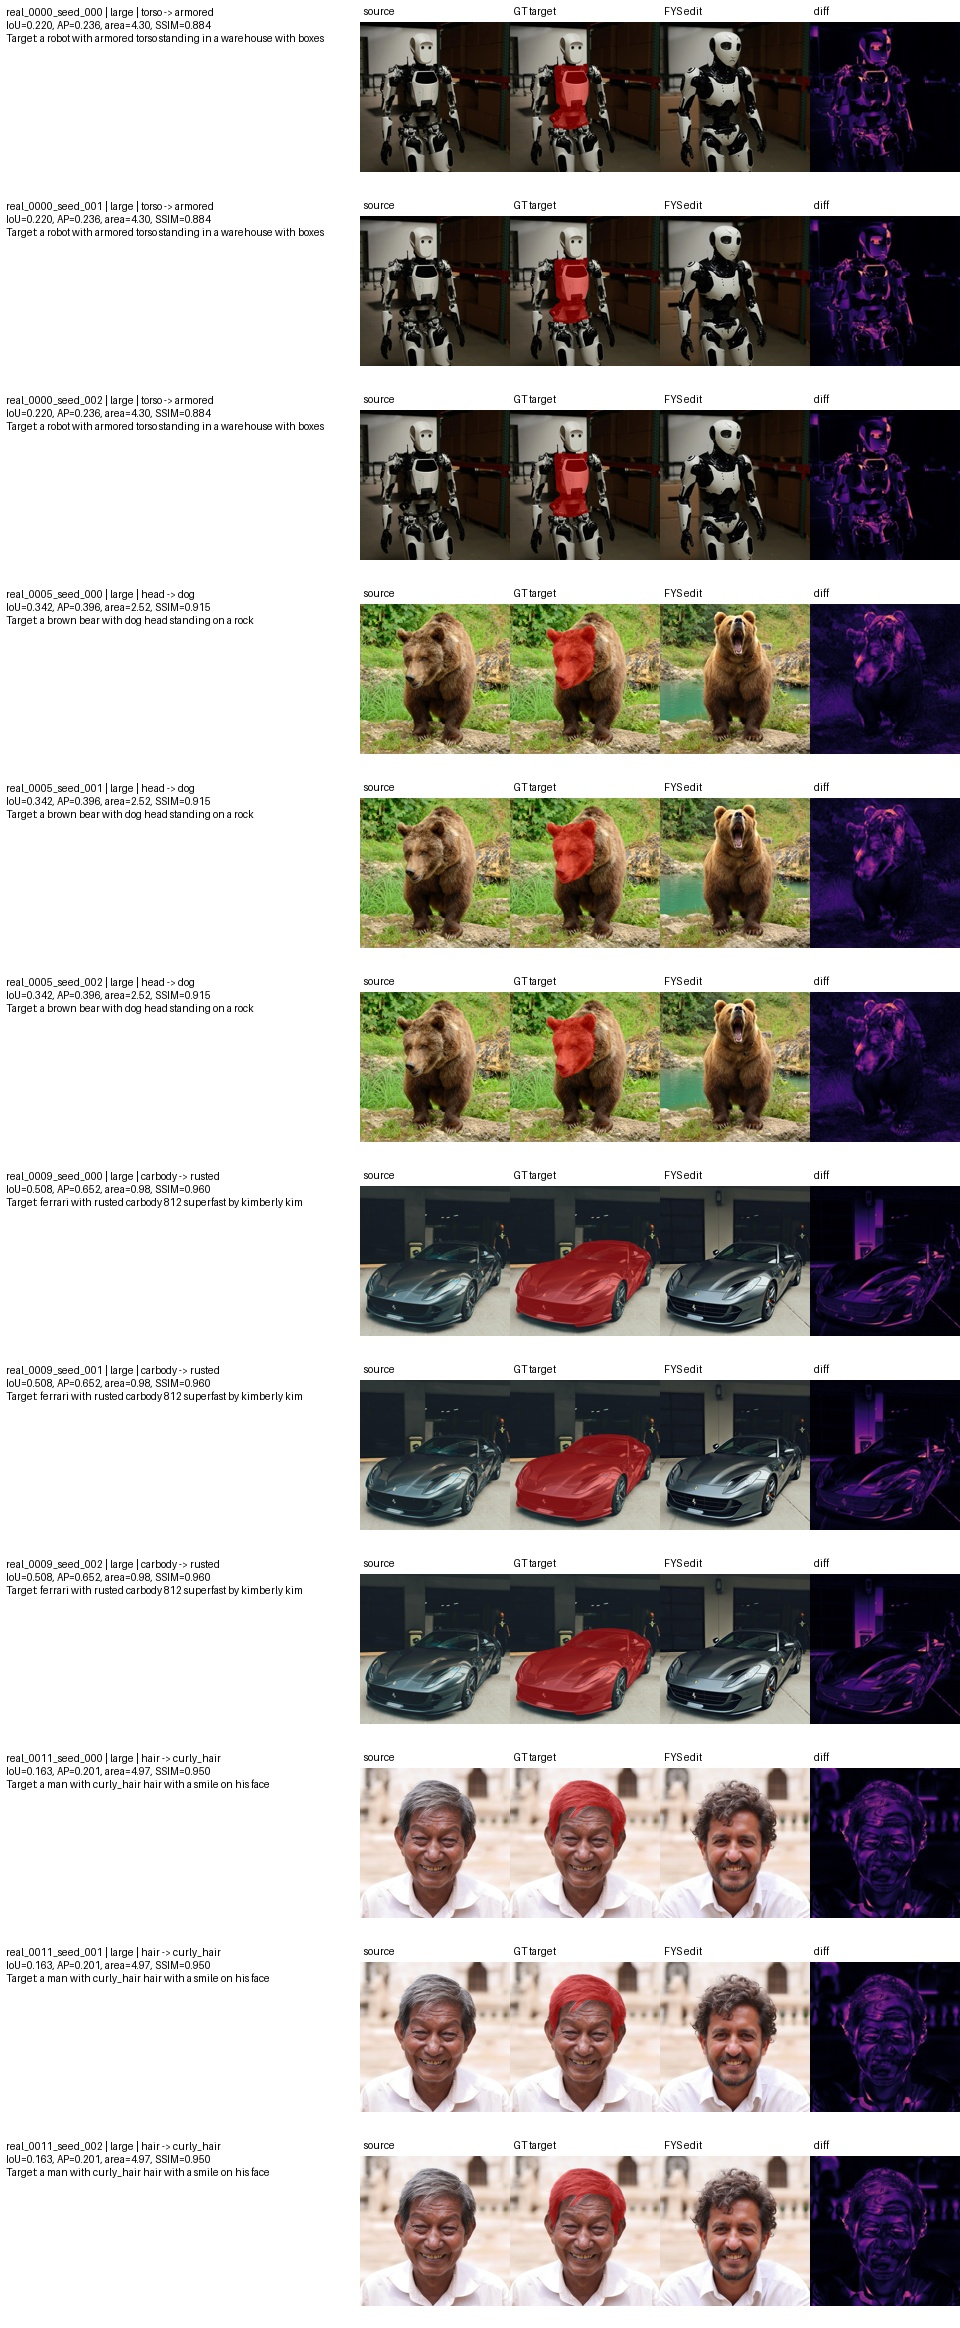

core/results/controlled_revision/figures/manual_scoring_sheet_part2.jpg


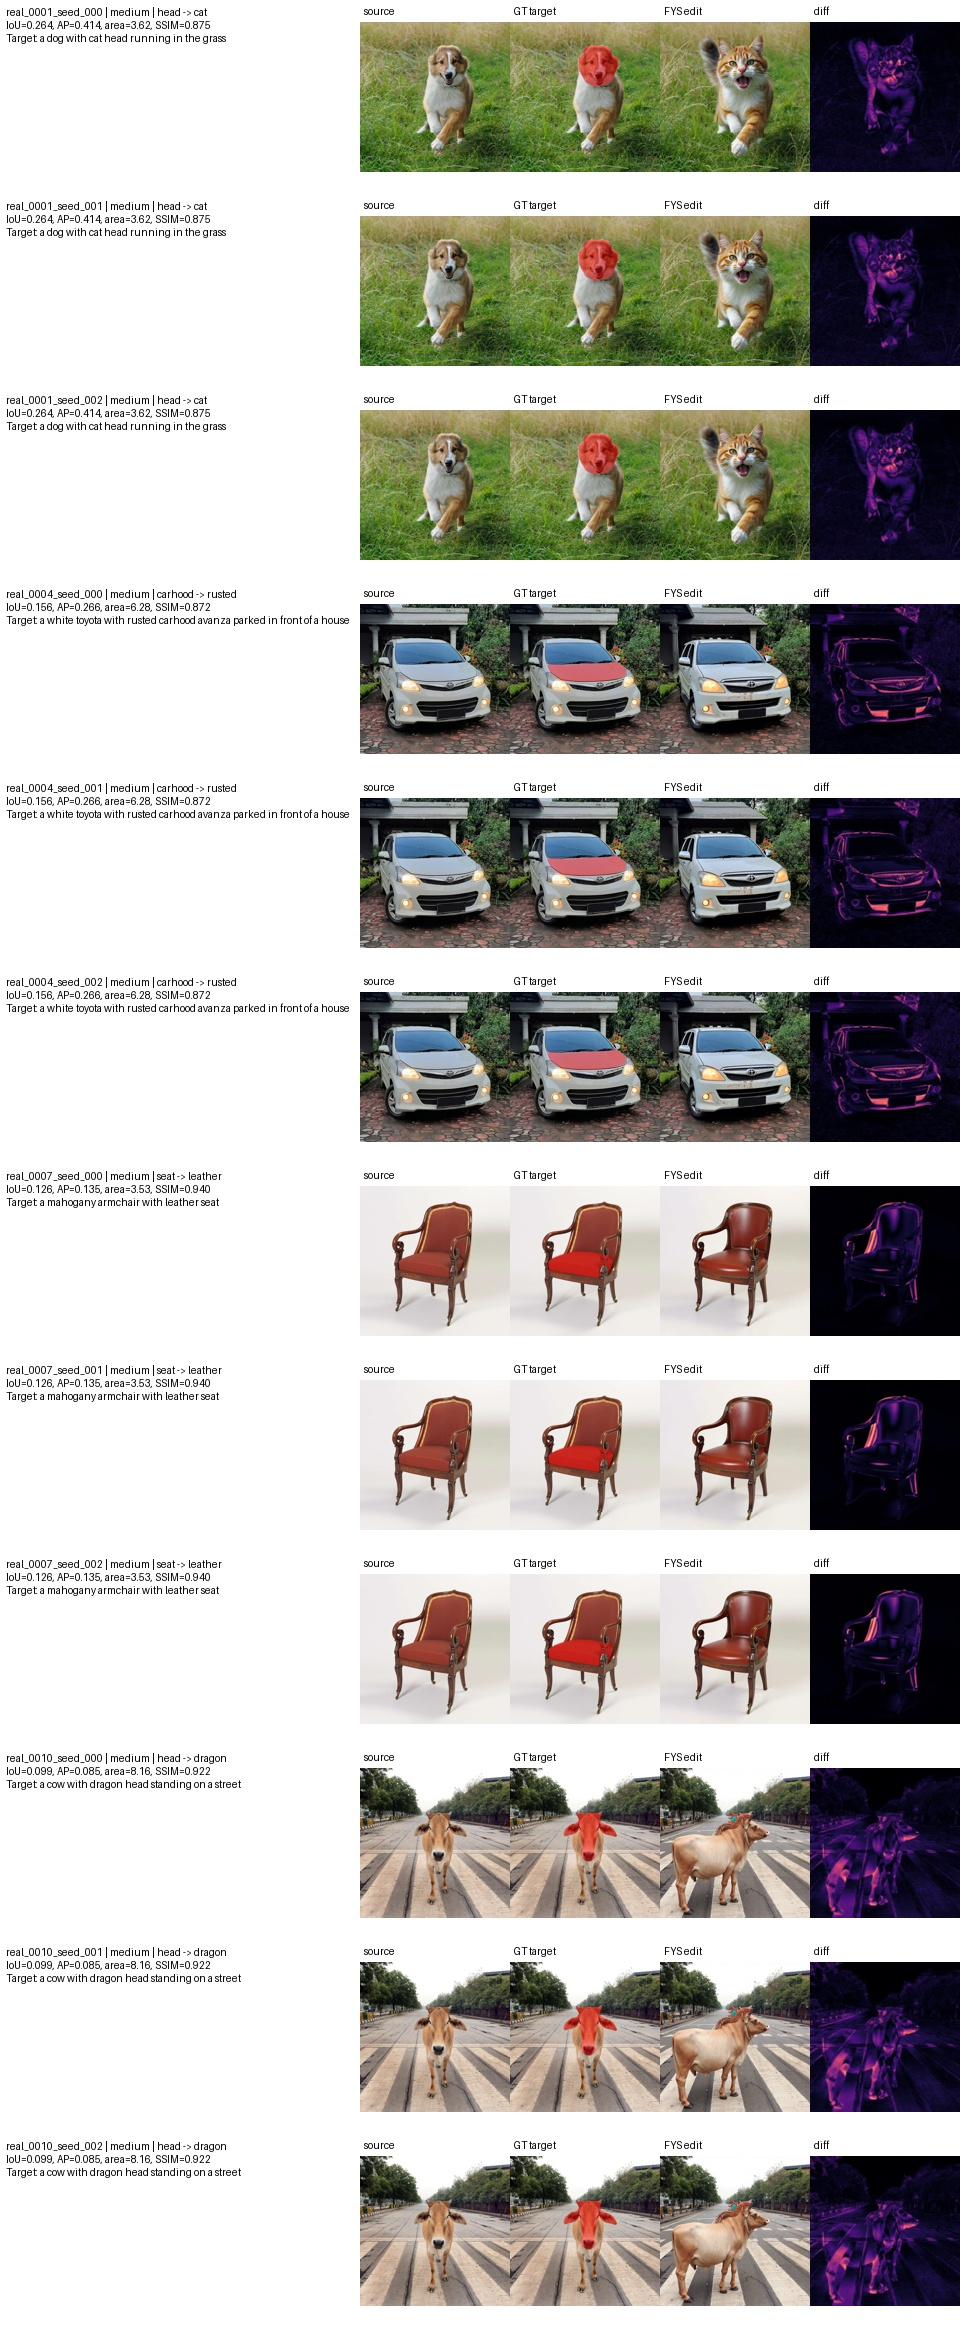

core/results/controlled_revision/figures/manual_scoring_sheet_part3.jpg


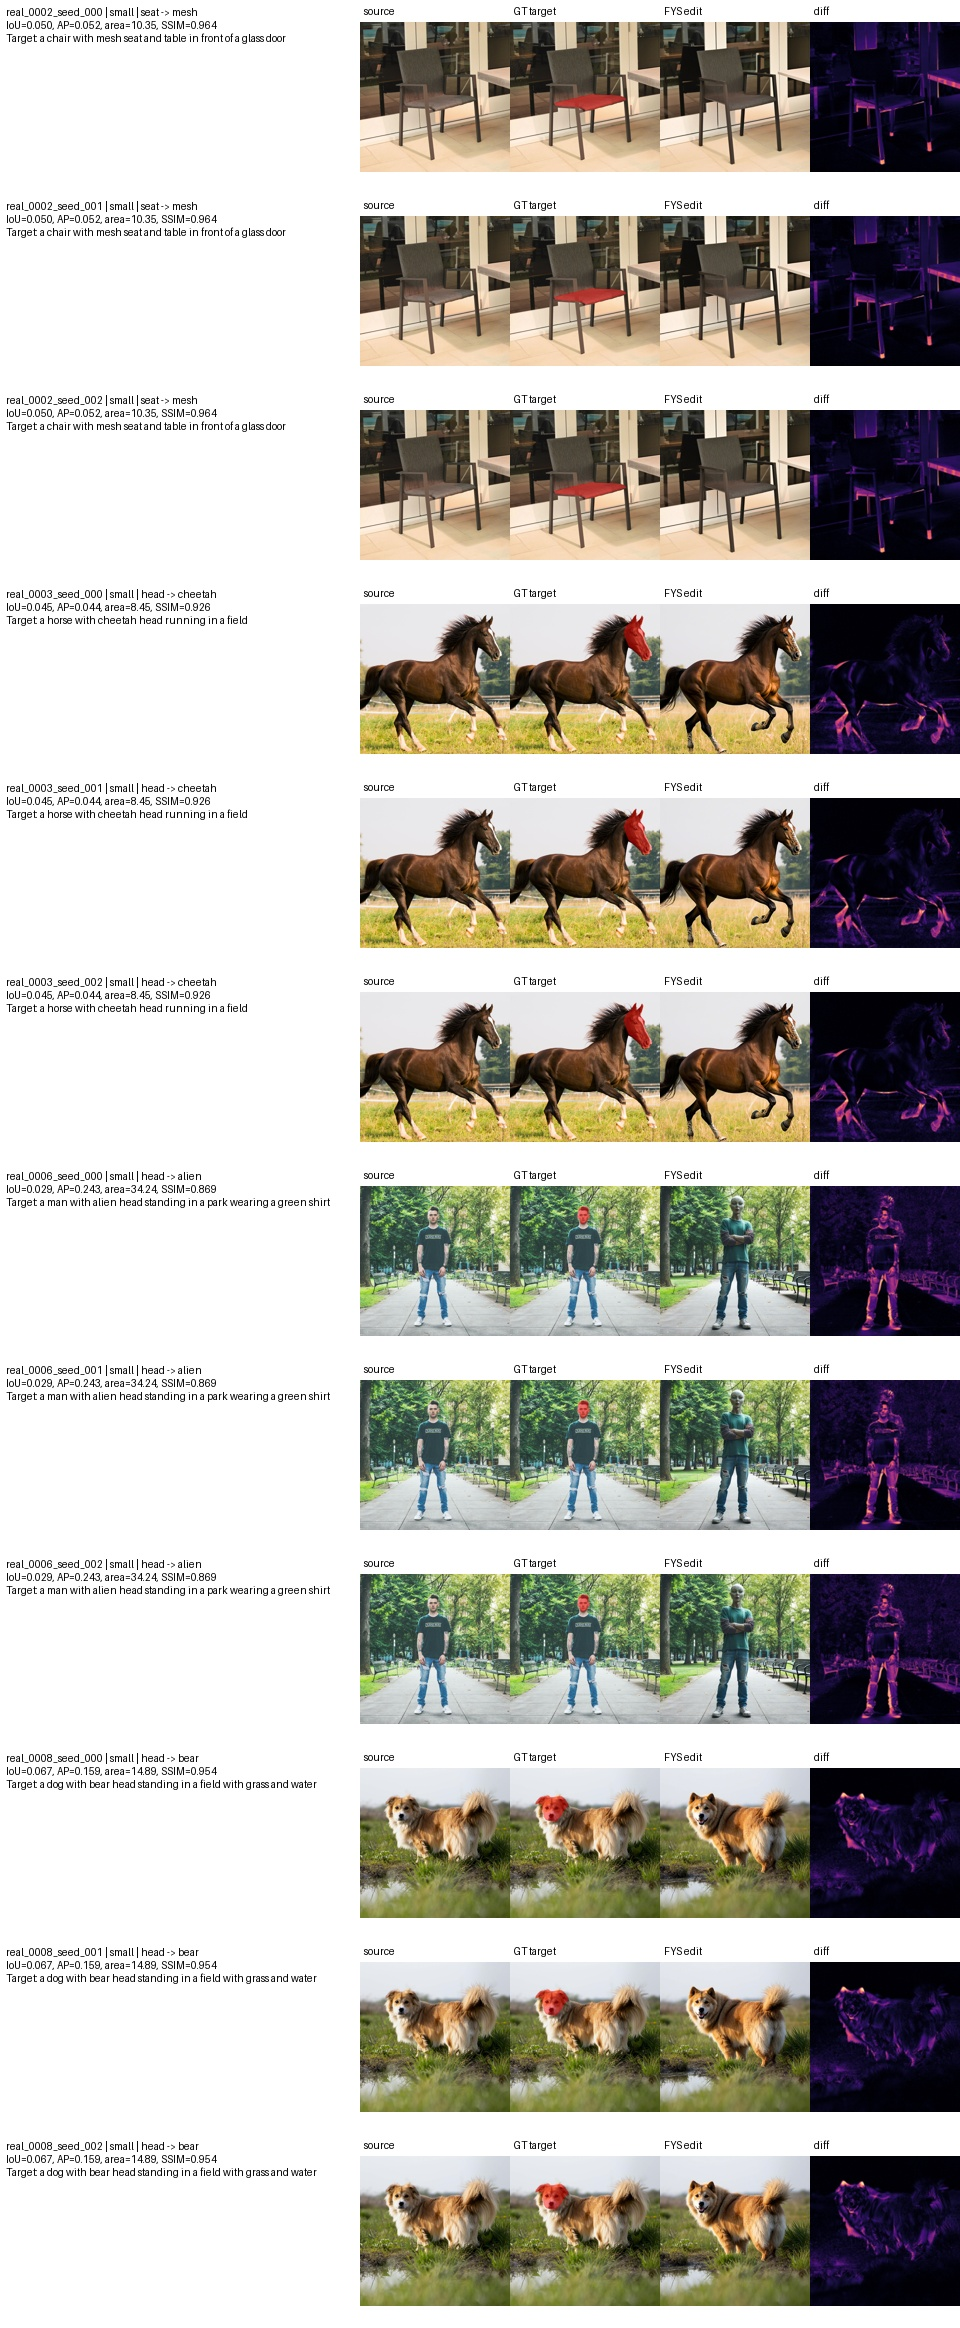

One full TDM / FLUX-attention diagnostic sheet preview
core/results/controlled_revision/figures/tdm_diagnostic_sheet_part1.jpg


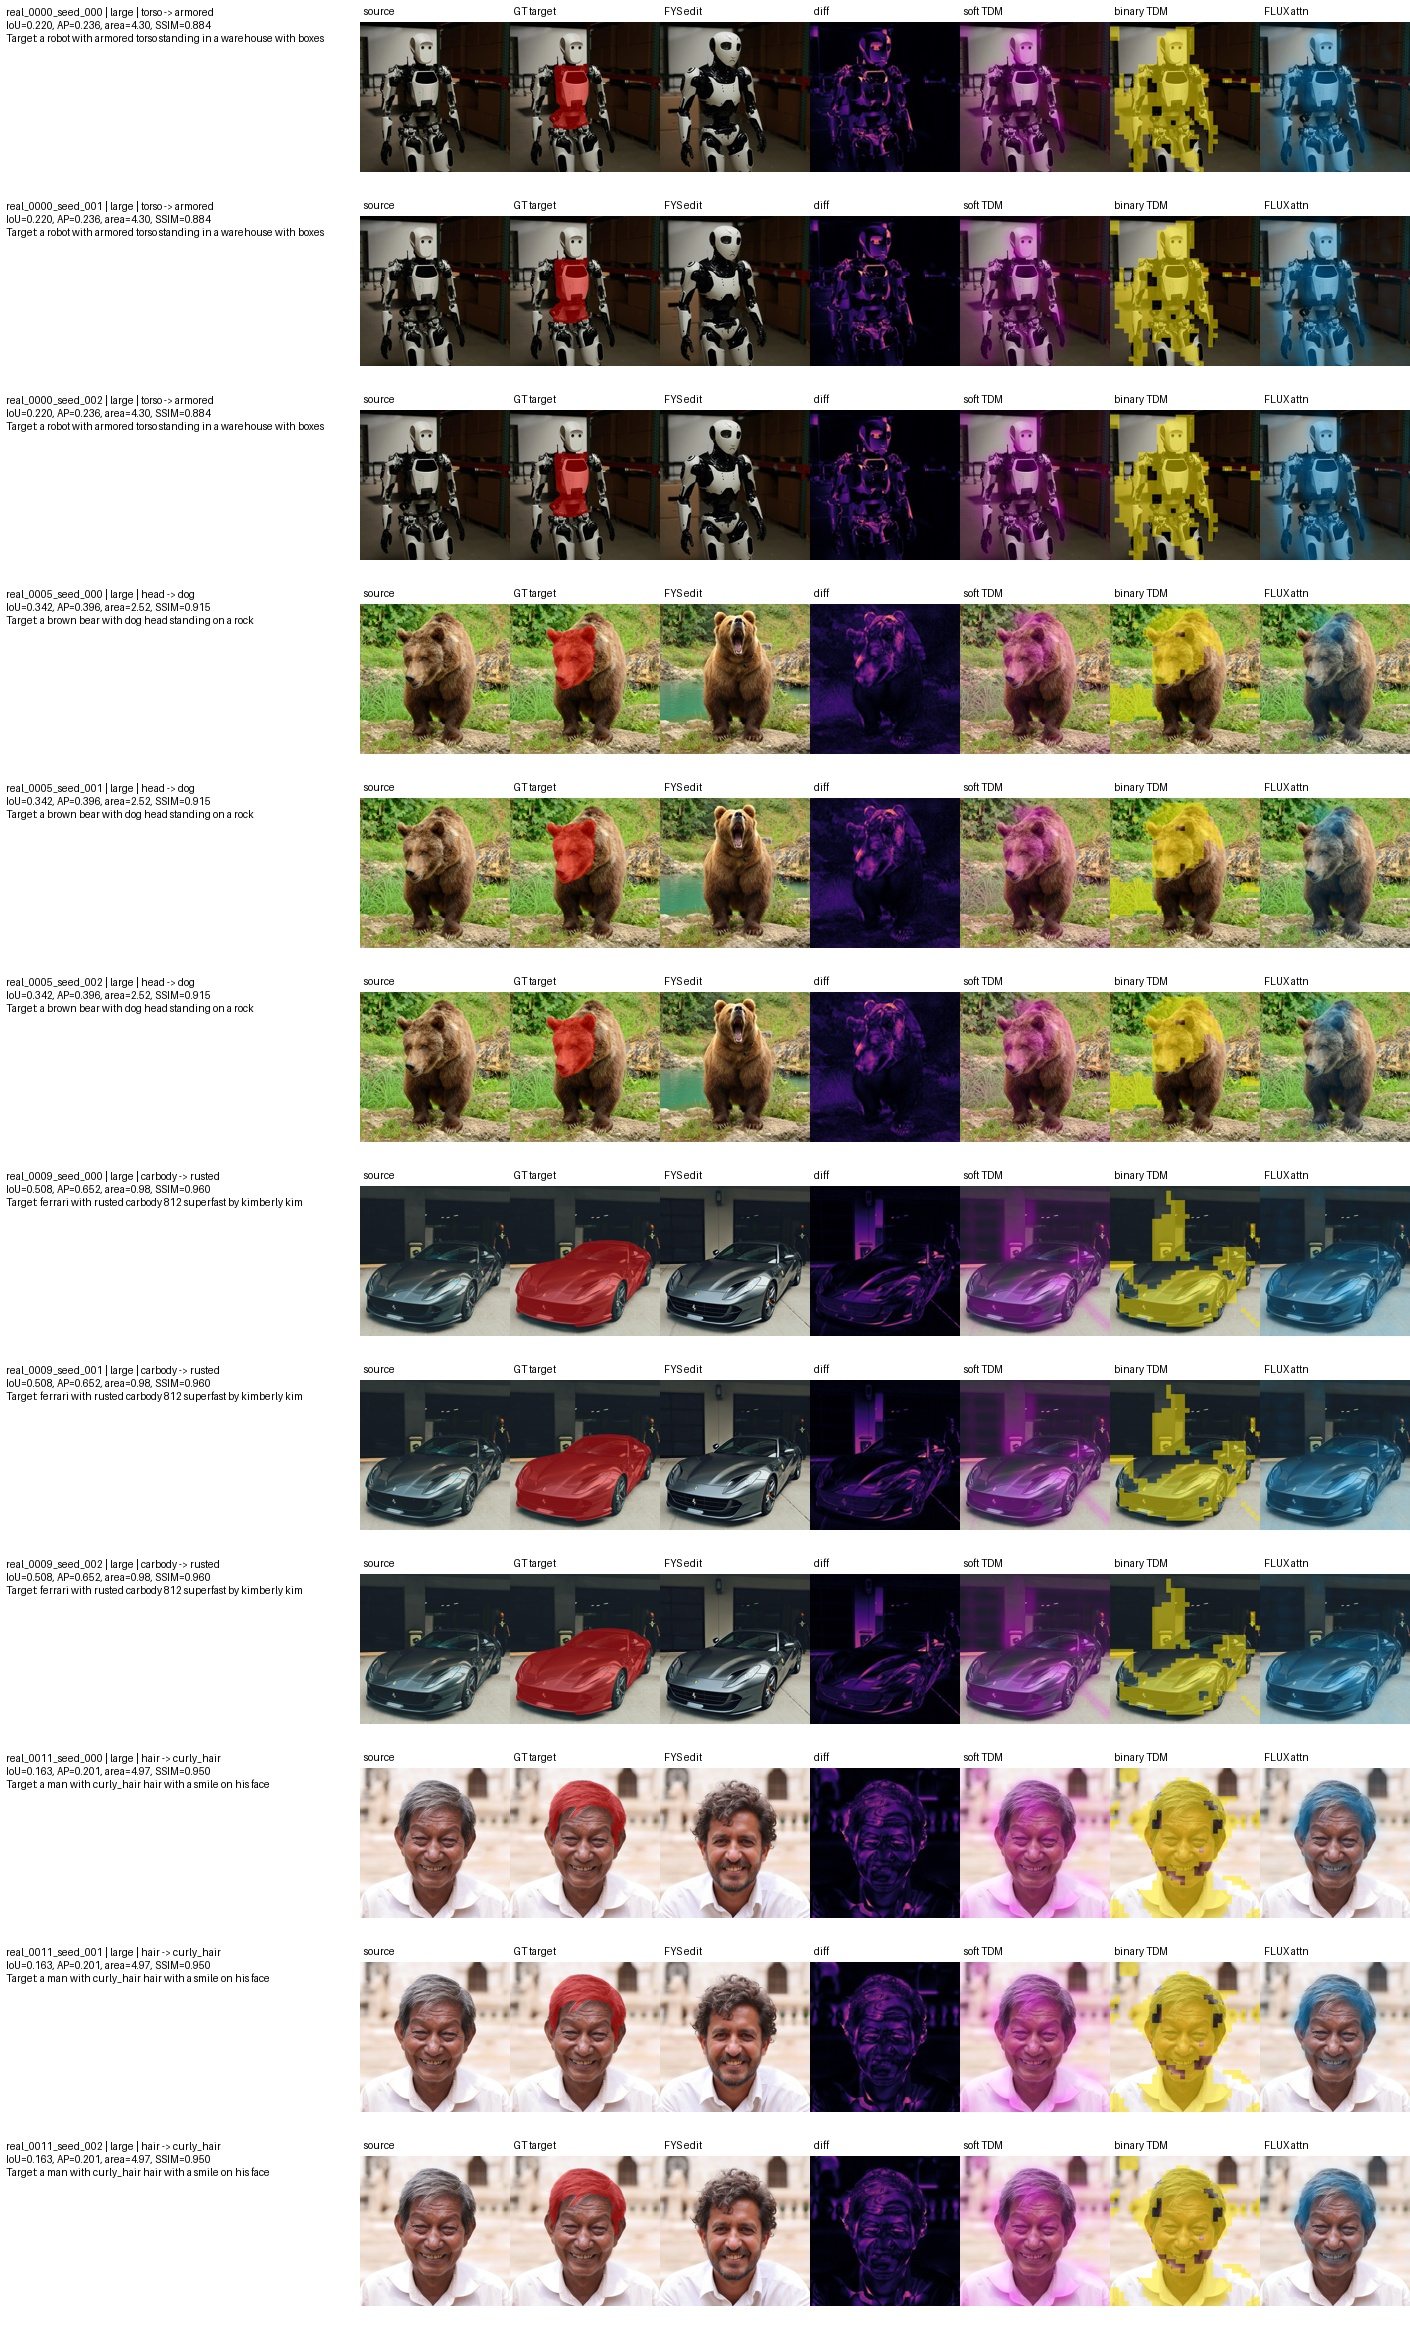

All TDM diagnostic sheets saved
core/results/controlled_revision/figures/tdm_diagnostic_sheet_part1.jpg
core/results/controlled_revision/figures/tdm_diagnostic_sheet_part2.jpg
core/results/controlled_revision/figures/tdm_diagnostic_sheet_part3.jpg


In [13]:
def to_uint8(image: np.ndarray) -> np.ndarray:
    return np.clip(image * 255, 0, 255).astype(np.uint8)


def overlay_mask(image: np.ndarray, mask: np.ndarray, color=(255, 0, 0), alpha=0.4) -> Image.Image:
    base = Image.fromarray(to_uint8(image)).convert('RGBA')
    overlay = Image.new('RGBA', base.size, (0, 0, 0, 0))
    mask_uint8 = (mask.astype(np.float32) * 255).clip(0, 255).astype(np.uint8)
    color_image = Image.new('RGBA', base.size, (*color, 0))
    color_image.putalpha(Image.fromarray((mask_uint8 * alpha).astype(np.uint8)))
    return Image.alpha_composite(base, color_image).convert('RGB')


def heatmap_image(score: np.ndarray, size: tuple[int, int]) -> Image.Image:
    fig, ax = plt.subplots(figsize=(2, 2), dpi=100)
    ax.imshow(score, cmap='magma', vmin=0, vmax=max(1e-6, float(np.nanmax(score))))
    ax.axis('off')
    fig.tight_layout(pad=0)
    fig.canvas.draw()
    data = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
    plt.close(fig)
    return Image.fromarray(data).resize(size, Image.Resampling.BICUBIC)


def difference_image(source: np.ndarray, edited: np.ndarray) -> Image.Image:
    diff = np.abs(source - edited).mean(axis=2)
    if diff.max() > diff.min():
        diff = (diff - diff.min()) / (diff.max() - diff.min())
    return heatmap_image(diff, Image.fromarray(to_uint8(source)).size)


def fit_text(text: str, width: int, font: ImageFont.ImageFont) -> list[str]:
    words = text.split()
    lines = []
    current = ''
    dummy = Image.new('RGB', (width, 10))
    draw = ImageDraw.Draw(dummy)
    for word in words:
        candidate = f'{current} {word}'.strip()
        if draw.textbbox((0, 0), candidate, font=font)[2] <= width:
            current = candidate
        else:
            if current:
                lines.append(current)
            current = word
    if current:
        lines.append(current)
    return lines


def build_review_panel(
    row: pd.Series,
    thumb_size=(150, 150),
    text_width=360,
    include_tdm: bool = False,
    include_flux_attention: bool = False,
) -> Image.Image:
    source = load_rgb(REPO_ROOT / row['source_image'])
    image_size = Image.open(REPO_ROOT / row['source_image']).size
    edited = load_rgb(REPO_ROOT / row['fys_image'], size=image_size)
    gt_mask = load_mask(REPO_ROOT / row['gt_mask'], size=image_size)

    panels = [
        Image.fromarray(to_uint8(source)),
        overlay_mask(source, gt_mask, color=(255, 0, 0), alpha=0.45),
        Image.fromarray(to_uint8(edited)),
        difference_image(source, edited),
    ]
    labels = ['source', 'GT target', 'FYS edit', 'diff']

    if include_tdm:
        soft_tdm = load_tdm(REPO_ROOT / row['smoothed_tdm_path'], image_size, is_binary=False)
        binary_tdm = load_tdm(REPO_ROOT / row['binary_tdm_path'], image_size, is_binary=True)
        panels.extend([
            overlay_mask(source, soft_tdm, color=(255, 0, 255), alpha=0.45),
            overlay_mask(source, binary_tdm, color=(255, 230, 0), alpha=0.5),
        ])
        labels.extend(['soft TDM', 'binary TDM'])

    if include_flux_attention and 'attention_smoothed_path' in row and pd.notna(row['attention_smoothed_path']):
        flux_attention = load_tdm(REPO_ROOT / row['attention_smoothed_path'], image_size, is_binary=False)
        panels.append(overlay_mask(source, flux_attention, color=(0, 160, 255), alpha=0.45))
        labels.append('FLUX attn')

    panels = [p.resize(thumb_size, Image.Resampling.BICUBIC) for p in panels]
    font = ImageFont.load_default()
    row_height = thumb_size[1] + 44
    canvas = Image.new('RGB', (text_width + len(panels) * thumb_size[0], row_height), 'white')
    draw = ImageDraw.Draw(canvas)
    text = (
        f"{row['run_uid']} | {row['part_size']} | {row['part']} -> {row['edit']}\n"
        f"IoU={row['binary_iou']:.3f}, AP={row['soft_ap']:.3f}, area={row['pred_to_gt_area_ratio']:.2f}, "
        f"SSIM={row['outside_mask_global_ssim']:.3f}\n"
        f"Target: {row['target_prompt']}"
    )
    y = 6
    for line in text.split('\n'):
        for wrapped in fit_text(line, text_width - 10, font):
            draw.text((6, y), wrapped, fill='black', font=font)
            y += 13
    x = text_width
    for label, panel in zip(labels, panels):
        canvas.paste(panel, (x, 22))
        draw.text((x + 4, 5), label, fill='black', font=font)
        x += thumb_size[0]
    return canvas

review_rows = manual_review.merge(
    fys_run_metrics[['run_uid', 'binary_iou', 'soft_ap', 'pred_to_gt_area_ratio', 'outside_mask_global_ssim']],
    on='run_uid',
    suffixes=('', '_metric'),
)

attention_paths = flux_attention_metrics[[
    'run_uid',
    'attention_smoothed_path',
    'attention_binary_path',
]].drop_duplicates('run_uid')
review_rows = review_rows.merge(attention_paths, on='run_uid', how='left')
review_rows = review_rows.sort_values(['part_size', 'case_uid', 'seed']).reset_index(drop=True)

def save_sheet(panels: list[Image.Image], rows_per_sheet: int, prefix: str) -> list[Path]:
    sheet_paths = []
    for sheet_idx in range(math.ceil(len(panels) / rows_per_sheet)):
        subset = panels[sheet_idx * rows_per_sheet:(sheet_idx + 1) * rows_per_sheet]
        width = max(p.width for p in subset)
        height = sum(p.height for p in subset)
        sheet = Image.new('RGB', (width, height), 'white')
        y = 0
        for panel in subset:
            sheet.paste(panel, (0, y))
            y += panel.height
        out_path = FIGURE_DIR / f'{prefix}_part{sheet_idx + 1}.jpg'
        sheet.save(out_path, quality=95)
        sheet_paths.append(out_path)
    return sheet_paths

manual_panels = [build_review_panel(row, include_tdm=False) for _, row in review_rows.iterrows()]
tdm_panels = [
    build_review_panel(row, include_tdm=True, include_flux_attention=True)
    for _, row in review_rows.iterrows()
]
manual_sheet_paths = save_sheet(manual_panels, rows_per_sheet=12, prefix='manual_scoring_sheet')
tdm_sheet_paths = save_sheet(tdm_panels, rows_per_sheet=12, prefix='tdm_diagnostic_sheet')

print('Manual scoring sheets')
for path in manual_sheet_paths:
    print(path.relative_to(REPO_ROOT))
    display(IPImage(filename=str(path)))

print('One full TDM / FLUX-attention diagnostic sheet preview')
if tdm_sheet_paths:
    print(tdm_sheet_paths[0].relative_to(REPO_ROOT))
    display(IPImage(filename=str(tdm_sheet_paths[0])))

print('All TDM diagnostic sheets saved')
for path in tdm_sheet_paths:
    print(path.relative_to(REPO_ROOT))

# manual_sheet_paths + tdm_sheet_paths

## 10. Compact Tables For

These tables are designed for a compact report summary. After the FLUX-attention baseline is added, concatenate the baseline table with the FYS table using a `method` column.

In [14]:
def mean_std(series: pd.Series, precision: int = 3) -> str:
    values = pd.to_numeric(series, errors='coerce').dropna()
    if values.empty:
        return 'NA'
    return f'{values.mean():.{precision}f} ± {values.std(ddof=1):.{precision}f}' if len(values) > 1 else f'{values.mean():.{precision}f}'

scored_review = manual_review.copy()
scored_review['local_edit_success_0_2_num'] = pd.to_numeric(scored_review['local_edit_success_0_2'], errors='coerce')
scored_review['outside_preservation_0_2_num'] = pd.to_numeric(scored_review['outside_preservation_0_2'], errors='coerce')
manual_metric_cols = [
    'run_uid',
    'local_edit_success_0_2_num',
    'outside_preservation_0_2_num',
    'failure_category',
]
metrics_with_manual = fys_run_metrics.merge(scored_review[manual_metric_cols], on='run_uid', how='left')

compact_rows = []
for part_size, group in metrics_with_manual.groupby('part_size'):
    compact_rows.append({
        'method': 'FYS TDM',
        'part_size': part_size,
        'n_runs': len(group),
        'manual_local_edit_success_0_2': mean_std(group['local_edit_success_0_2_num']),
        'manual_outside_preservation_0_2': mean_std(group['outside_preservation_0_2_num']),
        'binary_iou': mean_std(group['binary_iou']),
        'soft_ap': mean_std(group['soft_ap']),
        'pred_to_gt_area_ratio': mean_std(group['pred_to_gt_area_ratio'], precision=2),
        'soft_inside_gt_mass': mean_std(group['soft_inside_gt_mass']),
        'outside_mask_psnr': mean_std(group['outside_mask_psnr'], precision=2),
        'outside_mask_global_ssim': mean_std(group['outside_mask_global_ssim']),
        'outside_mask_lpips': mean_std(group['outside_mask_lpips']),
    })

for part_size, group in flux_attention_metrics.groupby('part_size'):
    compact_rows.append({
        'method': 'FLUX target-token attention',
        'part_size': part_size,
        'n_runs': len(group),
        'manual_local_edit_success_0_2': 'NA',
        'manual_outside_preservation_0_2': 'NA',
        'binary_iou': mean_std(group['binary_iou']),
        'soft_ap': mean_std(group['soft_ap']),
        'pred_to_gt_area_ratio': mean_std(group['pred_to_gt_area_ratio'], precision=2),
        'soft_inside_gt_mass': mean_std(group['soft_inside_gt_mass']),
        'outside_mask_psnr': 'NA',
        'outside_mask_global_ssim': 'NA',
        'outside_mask_lpips': 'NA',
    })

compact_summary = pd.DataFrame(compact_rows)
method_order = {'FYS TDM': 0, 'FLUX target-token attention': 1}
size_order = {'large': 0, 'medium': 1, 'small': 2}
compact_summary['_method_order'] = compact_summary['method'].map(method_order)
compact_summary['_size_order'] = compact_summary['part_size'].map(size_order)
compact_summary = compact_summary.sort_values(['_method_order', '_size_order']).drop(columns=['_method_order', '_size_order'])
compact_summary_path = OUTPUT_DIR / 'compact_fys_summary.csv'
compact_summary.to_csv(compact_summary_path, index=False)
print('saved:', compact_summary_path)
display(compact_summary)

manual_completion = scored_review[[
    'local_edit_success_0_2_num',
    'outside_preservation_0_2_num',
    'failure_category',
]].notna().sum().rename('filled_count').to_frame()
manual_completion['total_runs'] = len(scored_review)
display(manual_completion)

localization_comparison = compact_summary[[
    'method', 'part_size', 'n_runs', 'binary_iou', 'soft_ap', 'pred_to_gt_area_ratio', 'soft_inside_gt_mass'
]].copy()
localization_comparison_path = OUTPUT_DIR / 'localization_comparison.csv'
localization_comparison.to_csv(localization_comparison_path, index=False)
print('saved:', localization_comparison_path)
display(localization_comparison)

saved: /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/controlled_revision/compact_fys_summary.csv


,method,part_size,n_runs,manual_local_edit_success_0_2,manual_outside_preservation_0_2,binary_iou,soft_ap,pred_to_gt_area_ratio,soft_inside_gt_mass,outside_mask_psnr,outside_mask_global_ssim,outside_mask_lpips
0,FYS TDM,large,12,1.250 ± 0.866,0.750 ± 0.452,0.308 ± 0.138,0.371 ± 0.186,3.19 ± 1.63,0.255 ± 0.156,21.16 ± 1.32,0.927 ± 0.031,0.184 ± 0.023
1,FYS TDM,medium,12,1.000 ± 1.044,1.250 ± 0.866,0.161 ± 0.066,0.225 ± 0.133,5.40 ± 2.03,0.113 ± 0.031,20.04 ± 1.54,0.902 ± 0.031,0.196 ± 0.044
2,FYS TDM,small,12,0.750 ± 0.866,0.750 ± 0.866,0.048 ± 0.014,0.124 ± 0.086,16.98 ± 10.69,0.041 ± 0.012,19.87 ± 1.97,0.928 ± 0.039,0.194 ± 0.033
3,FLUX target-token attention,large,12,NA,NA,0.425 ± 0.174,0.609 ± 0.196,2.38 ± 1.26,0.352 ± 0.163,NA,NA,NA
4,FLUX target-token attention,medium,12,NA,NA,0.267 ± 0.108,0.338 ± 0.146,3.43 ± 1.14,0.171 ± 0.089,NA,NA,NA
5,FLUX target-token attention,small,12,NA,NA,0.240 ± 0.276,0.501 ± 0.415,13.09 ± 15.09,0.094 ± 0.048,NA,NA,NA


,filled_count,total_runs
local_edit_success_0_2_num,36,36
outside_preservation_0_2_num,36,36
failure_category,36,36


saved: /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/controlled_revision/localization_comparison.csv


,method,part_size,n_runs,binary_iou,soft_ap,pred_to_gt_area_ratio,soft_inside_gt_mass
0,FYS TDM,large,12,0.308 ± 0.138,0.371 ± 0.186,3.19 ± 1.63,0.255 ± 0.156
1,FYS TDM,medium,12,0.161 ± 0.066,0.225 ± 0.133,5.40 ± 2.03,0.113 ± 0.031
2,FYS TDM,small,12,0.048 ± 0.014,0.124 ± 0.086,16.98 ± 10.69,0.041 ± 0.012
3,FLUX target-token attention,large,12,0.425 ± 0.174,0.609 ± 0.196,2.38 ± 1.26,0.352 ± 0.163
4,FLUX target-token attention,medium,12,0.267 ± 0.108,0.338 ± 0.146,3.43 ± 1.14,0.171 ± 0.089
5,FLUX target-token attention,small,12,0.240 ± 0.276,0.501 ± 0.415,13.09 ± 15.09,0.094 ± 0.048


## 11. Representative Case Candidates

Automatically suggest candidate cases for qualitative reporting. Final selection should be made after manual review because edit success and preservation quality require human judgment.

,candidate_type,run_uid,case_uid,seed,part_size,part,edit,binary_iou,soft_ap,pred_to_gt_area_ratio,outside_mask_global_ssim,fys_image,reason,flux_attention_binary_iou,flux_attention_soft_ap,flux_attention_pred_to_gt_area_ratio,flux_attention_soft_inside_gt_mass,attention_smoothed_path,attention_binary_path
0,best_fys_localization,real_0009_seed_002,real_0009,2,large,carbody,rusted,0.508312,0.651605,0.980005,0.959767,core/results/follow_your_shape/real_0009/seed_...,binary_iou sorted descending; prefer distinct ...,0.608181,0.814624,1.478313,0.584623,core/results/flux_attention_baseline/real_0009...,core/results/flux_attention_baseline/real_0009...
1,worst_fys_over_localization,real_0006_seed_000,real_0006,0,small,head,alien,0.029204,0.242928,34.242038,0.869110,core/results/follow_your_shape/real_0006/seed_...,pred_to_gt_area_ratio sorted descending; prefe...,0.026859,0.055930,37.231423,0.019802,core/results/flux_attention_baseline/real_0006...,core/results/flux_attention_baseline/real_0006...
2,weak_fys_localization,real_0003_seed_000,real_0003,0,small,head,cheetah,0.044741,0.043715,8.450039,0.925958,core/results/follow_your_shape/real_0003/seed_...,soft_inside_gt_mass sorted ascending; prefer d...,0.691908,0.939395,0.756229,0.139197,core/results/flux_attention_baseline/real_0003...,core/results/flux_attention_baseline/real_0003...
3,possible_fys_preservation_drift,real_0004_seed_000,real_0004,0,medium,carhood,rusted,0.156007,0.265689,6.283438,0.872189,core/results/follow_your_shape/real_0004/seed_...,outside_mask_global_ssim sorted ascending; pre...,0.133395,0.163554,4.443939,0.085380,core/results/flux_attention_baseline/real_0004...,core/results/flux_attention_baseline/real_0004...


/var/folders/h8/4tqmd6qs19zcccxsg4_xc7c00000gp/T/ipykernel_35882/3041514674.py:26: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray((norm * 255).astype(np.uint8), mode='L')


saved: core/results/controlled_revision/figures/representative_case_candidates_sheet.jpg


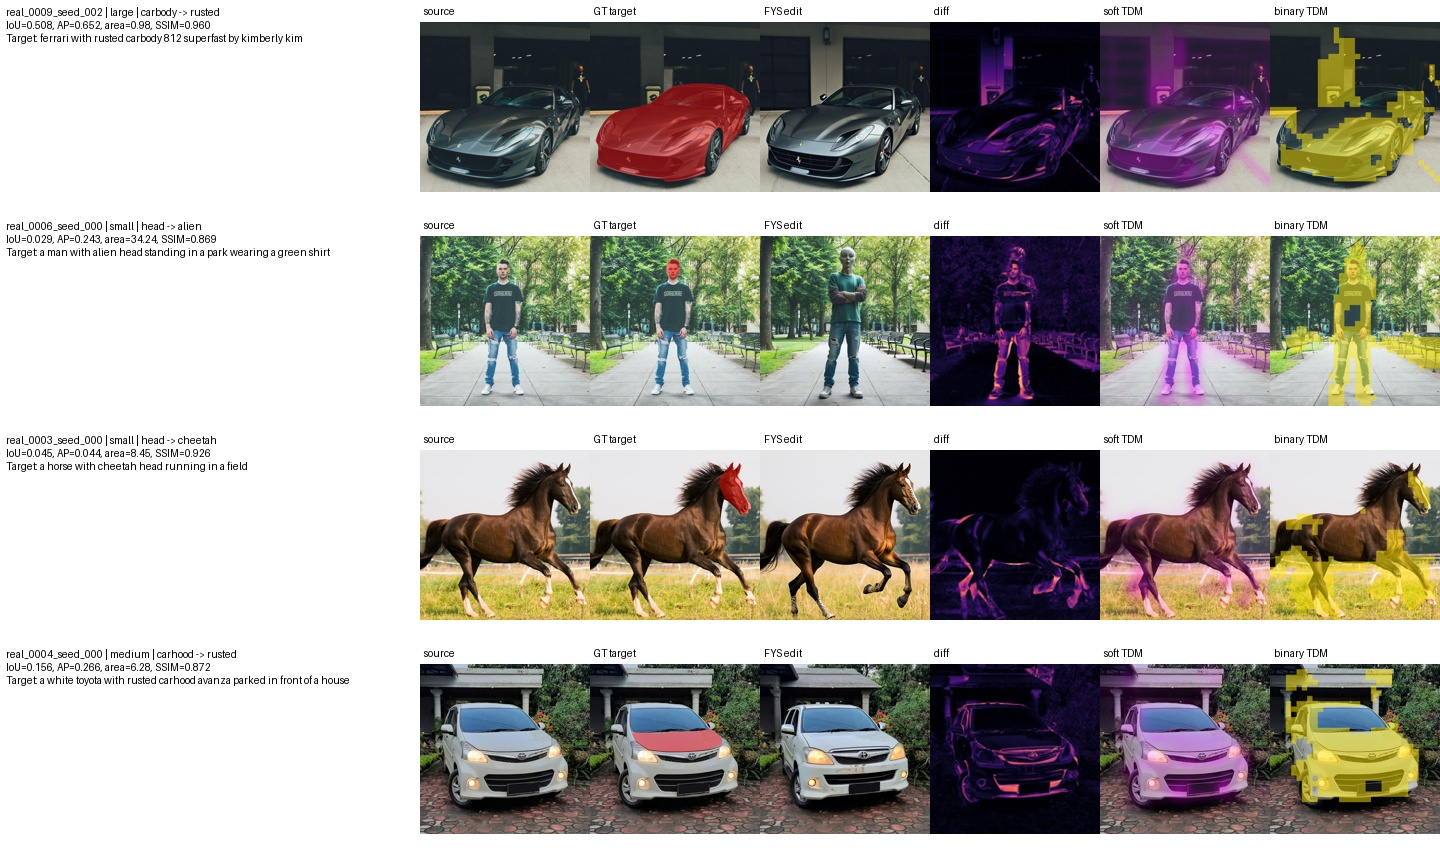

In [15]:
candidates = []
used_case_uids = set()
used_run_uids = set()

def add_candidate(label: str, frame: pd.DataFrame, sort_col: str, ascending: bool):
    if frame.empty:
        return

    candidate_frame = frame[~frame['case_uid'].isin(used_case_uids)].copy()
    if candidate_frame.empty:
        candidate_frame = frame[~frame['run_uid'].isin(used_run_uids)].copy()
    if candidate_frame.empty:
        candidate_frame = frame.copy()

    row = candidate_frame.sort_values(sort_col, ascending=ascending).iloc[0]
    candidates.append({
        'candidate_type': label,
        'run_uid': row['run_uid'],
        'case_uid': row['case_uid'],
        'seed': row['seed'],
        'part_size': row['part_size'],
        'part': row['part'],
        'edit': row['edit'],
        'binary_iou': row['binary_iou'],
        'soft_ap': row['soft_ap'],
        'pred_to_gt_area_ratio': row['pred_to_gt_area_ratio'],
        'outside_mask_global_ssim': row['outside_mask_global_ssim'],
        'fys_image': row['fys_image'],
        'reason': f'{sort_col} sorted {"ascending" if ascending else "descending"}; prefer distinct cases',
    })
    used_case_uids.add(row['case_uid'])
    used_run_uids.add(row['run_uid'])

add_candidate('best_fys_localization', fys_run_metrics, 'binary_iou', False)
add_candidate('worst_fys_over_localization', fys_run_metrics, 'pred_to_gt_area_ratio', False)
add_candidate('weak_fys_localization', fys_run_metrics, 'soft_inside_gt_mass', True)
add_candidate('possible_fys_preservation_drift', fys_run_metrics, 'outside_mask_global_ssim', True)

representative_candidates = pd.DataFrame(candidates)
representative_candidates = representative_candidates.merge(
    flux_attention_metrics[[
        'run_uid',
        'binary_iou',
        'soft_ap',
        'pred_to_gt_area_ratio',
        'soft_inside_gt_mass',
        'attention_smoothed_path',
        'attention_binary_path',
    ]].rename(columns={
        'binary_iou': 'flux_attention_binary_iou',
        'soft_ap': 'flux_attention_soft_ap',
        'pred_to_gt_area_ratio': 'flux_attention_pred_to_gt_area_ratio',
        'soft_inside_gt_mass': 'flux_attention_soft_inside_gt_mass',
    }),
    on='run_uid',
    how='left',
)
display(representative_candidates)

# Visual sheet for the automatically suggested candidates. Final case selection
# should still use manual review scores.
if not representative_candidates.empty:
    candidate_rows = review_rows[review_rows['run_uid'].isin(representative_candidates['run_uid'])].copy()
    candidate_rows = candidate_rows.merge(
        flux_attention_metrics[['run_uid', 'attention_smoothed_path', 'attention_binary_path']],
        on='run_uid',
        how='left',
    )
    candidate_rows['candidate_order'] = candidate_rows['run_uid'].map({uid: i for i, uid in enumerate(representative_candidates['run_uid'])})
    candidate_rows = candidate_rows.sort_values('candidate_order')
    candidate_panels = [
        build_review_panel(row, thumb_size=(170, 170), text_width=420, include_tdm=True, include_flux_attention=True)
        for _, row in candidate_rows.iterrows()
    ]
    width = max(panel.width for panel in candidate_panels)
    height = sum(panel.height for panel in candidate_panels)
    candidate_sheet = Image.new('RGB', (width, height), 'white')
    y = 0
    for panel in candidate_panels:
        candidate_sheet.paste(panel, (0, y))
        y += panel.height
    candidate_sheet_path = FIGURE_DIR / 'representative_case_candidates_sheet.jpg'
    candidate_sheet.save(candidate_sheet_path, quality=95)
    print('saved:', candidate_sheet_path.relative_to(REPO_ROOT))
    display(IPImage(filename=str(candidate_sheet_path)))

## 12. Current Findings Draft

This cell generates a data-backed draft summary from the executed FYS metrics. Treat it as a draft until manual scores and the FLUX-attention baseline are added.

In [16]:
overall = metrics_with_manual[metric_cols].agg(['mean', 'std', 'median']).T
print('Controlled revision draft summary')
print('-----------------------------------')
print(f"FYS runs evaluated: {len(metrics_with_manual)} from {metrics_with_manual['case_uid'].nunique()} cases and {metrics_with_manual['seed'].nunique()} seeds.")
print(f"FLUX attention baseline runs evaluated: {len(flux_attention_metrics)} from {flux_attention_metrics['case_uid'].nunique()} cases and {flux_attention_metrics['seed'].nunique()} seeds.")
print(f"Manual local-edit success rows: {metrics_with_manual['local_edit_success_0_2_num'].notna().sum()} / {len(metrics_with_manual)}")
print(f"Manual outside-preservation rows: {metrics_with_manual['outside_preservation_0_2_num'].notna().sum()} / {len(metrics_with_manual)}")
if metrics_with_manual['local_edit_success_0_2_num'].notna().any():
    print(f"Mean manual local-edit success: {metrics_with_manual['local_edit_success_0_2_num'].mean():.3f} / 2")
if metrics_with_manual['outside_preservation_0_2_num'].notna().any():
    print(f"Mean manual outside preservation: {metrics_with_manual['outside_preservation_0_2_num'].mean():.3f} / 2")
print(f"FYS median binary IoU: {metrics_with_manual['binary_iou'].median():.3f}")
print(f"FLUX attention median binary IoU: {flux_attention_metrics['binary_iou'].median():.3f}")
print(f"FYS median predicted/GT area ratio: {metrics_with_manual['pred_to_gt_area_ratio'].median():.2f}")
print(f"FLUX attention median predicted/GT area ratio: {flux_attention_metrics['pred_to_gt_area_ratio'].median():.2f}")
print(f"FYS median outside-mask global SSIM: {metrics_with_manual['outside_mask_global_ssim'].median():.3f}")
if metrics_with_manual['outside_mask_lpips'].notna().any():
    print(f"FYS median outside-mask LPIPS: {metrics_with_manual['outside_mask_lpips'].median():.3f}")
else:
    print('Outside-mask LPIPS was not computed in this environment.')
print()
print('Compact summary:')
display(compact_summary)
print()
print('Localization-only comparison:')
display(localization_comparison)

Controlled revision draft summary
-----------------------------------
FYS runs evaluated: 36 from 12 cases and 3 seeds.
FLUX attention baseline runs evaluated: 36 from 12 cases and 3 seeds.
Manual local-edit success rows: 36 / 36
Manual outside-preservation rows: 36 / 36
Mean manual local-edit success: 1.000 / 2
Mean manual outside preservation: 0.917 / 2
FYS median binary IoU: 0.141
FLUX attention median binary IoU: 0.256
FYS median predicted/GT area ratio: 5.63
FLUX attention median predicted/GT area ratio: 3.57
FYS median outside-mask global SSIM: 0.924
FYS median outside-mask LPIPS: 0.195

Compact summary:


,method,part_size,n_runs,manual_local_edit_success_0_2,manual_outside_preservation_0_2,binary_iou,soft_ap,pred_to_gt_area_ratio,soft_inside_gt_mass,outside_mask_psnr,outside_mask_global_ssim,outside_mask_lpips
0,FYS TDM,large,12,1.250 ± 0.866,0.750 ± 0.452,0.308 ± 0.138,0.371 ± 0.186,3.19 ± 1.63,0.255 ± 0.156,21.16 ± 1.32,0.927 ± 0.031,0.184 ± 0.023
1,FYS TDM,medium,12,1.000 ± 1.044,1.250 ± 0.866,0.161 ± 0.066,0.225 ± 0.133,5.40 ± 2.03,0.113 ± 0.031,20.04 ± 1.54,0.902 ± 0.031,0.196 ± 0.044
2,FYS TDM,small,12,0.750 ± 0.866,0.750 ± 0.866,0.048 ± 0.014,0.124 ± 0.086,16.98 ± 10.69,0.041 ± 0.012,19.87 ± 1.97,0.928 ± 0.039,0.194 ± 0.033
3,FLUX target-token attention,large,12,NA,NA,0.425 ± 0.174,0.609 ± 0.196,2.38 ± 1.26,0.352 ± 0.163,NA,NA,NA
4,FLUX target-token attention,medium,12,NA,NA,0.267 ± 0.108,0.338 ± 0.146,3.43 ± 1.14,0.171 ± 0.089,NA,NA,NA
5,FLUX target-token attention,small,12,NA,NA,0.240 ± 0.276,0.501 ± 0.415,13.09 ± 15.09,0.094 ± 0.048,NA,NA,NA



Localization-only comparison:


,method,part_size,n_runs,binary_iou,soft_ap,pred_to_gt_area_ratio,soft_inside_gt_mass
0,FYS TDM,large,12,0.308 ± 0.138,0.371 ± 0.186,3.19 ± 1.63,0.255 ± 0.156
1,FYS TDM,medium,12,0.161 ± 0.066,0.225 ± 0.133,5.40 ± 2.03,0.113 ± 0.031
2,FYS TDM,small,12,0.048 ± 0.014,0.124 ± 0.086,16.98 ± 10.69,0.041 ± 0.012
3,FLUX target-token attention,large,12,0.425 ± 0.174,0.609 ± 0.196,2.38 ± 1.26,0.352 ± 0.163
4,FLUX target-token attention,medium,12,0.267 ± 0.108,0.338 ± 0.146,3.43 ± 1.14,0.171 ± 0.089
5,FLUX target-token attention,small,12,0.240 ± 0.276,0.501 ± 0.415,13.09 ± 15.09,0.094 ± 0.048


## 13. Remaining Notes

The notebook now evaluates both the FYS TDM localization map and the plain-FLUX target-token attention baseline. The remaining writing task is to use the compact comparison table and representative case sheet in the final 1-2 page note.